In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats  

In [2]:
df = pd.read_csv("E:/Project/Submissions/Datasets/Final_Data.csv")

In [3]:
df

,day,energy_median,energy_mean,energy_max,energy_std,energy_sum,energy_min,time,temperatureMax,windBearing,...,cloudy,fog,partly-cloudy-day,partly-cloudy-night,wind,rain,snow,year,month,date
0,2011-11-24,0.2250,0.252812,0.625,0.135267,12.135,0.092,23:00:00,15.57,208,...,0,0,1,0,0,1,0,2011,11,24
1,2011-11-24,0.0480,0.048000,0.049,0.000583,2.304,0.047,23:00:00,15.57,208,...,0,0,1,0,0,1,0,2011,11,24
2,2011-11-24,0.1250,0.174875,0.611,0.130562,8.394,0.036,23:00:00,15.57,208,...,0,0,1,0,0,1,0,2011,11,24
3,2011-11-24,0.0760,0.096250,0.279,0.068798,4.620,0.023,23:00:00,15.57,208,...,0,0,1,0,0,1,0,2011,11,24
4,2011-11-24,0.2910,0.297042,0.769,0.112216,14.258,0.127,23:00:00,15.57,208,...,0,0,1,0,0,1,0,2011,11,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2949619,2014-02-27,0.0020,0.009729,0.038,0.012880,0.467,0.000,23:00:00,9.21,302,...,0,0,1,0,0,1,0,2014,2,27
2949620,2014-02-27,0.0820,0.159812,1.161,0.235171,7.671,0.025,23:00:00,9.21,302,...,0,0,1,0,0,1,0,2014,2,27
2949621,2014-02-27,0.1460,0.211208,0.877,0.228802,10.138,0.023,23:00:00,9.21,302,...,0,0,1,0,0,1,0,2014,2,27
2949622,2014-02-27,0.0295,0.038000,0.475,0.066159,1.824,0.009,23:00:00,9.21,302,...,0,0,1,0,0,1,0,2014,2,27


In [4]:
df.columns

Index(['day', 'energy_median', 'energy_mean', 'energy_max', 'energy_std',
       'energy_sum', 'energy_min', 'time', 'temperatureMax', 'windBearing',
       'dewPoint', 'cloudCover', 'windSpeed', 'pressure',
       'apparentTemperatureHigh', 'visibility', 'humidity',
       'apparentTemperatureLow', 'apparentTemperatureMax', 'uvIndex', 'time.1',
       'temperatureLow', 'temperatureMin', 'temperatureHigh',
       'apparentTemperatureMin', 'moonPhase', 'clear-day', 'cloudy', 'fog',
       'partly-cloudy-day', 'partly-cloudy-night', 'wind', 'rain', 'snow',
       'year', 'month', 'date'],
      dtype='object')

In [5]:
# Load dataset (ensure 'day' is the index)
df['day'] = pd.to_datetime(df['day'])
df.set_index('day', inplace=True)

In [6]:
# Selecting target variable (energy_sum as an example)
target_col = 'energy_sum'
df_re = df[target_col]

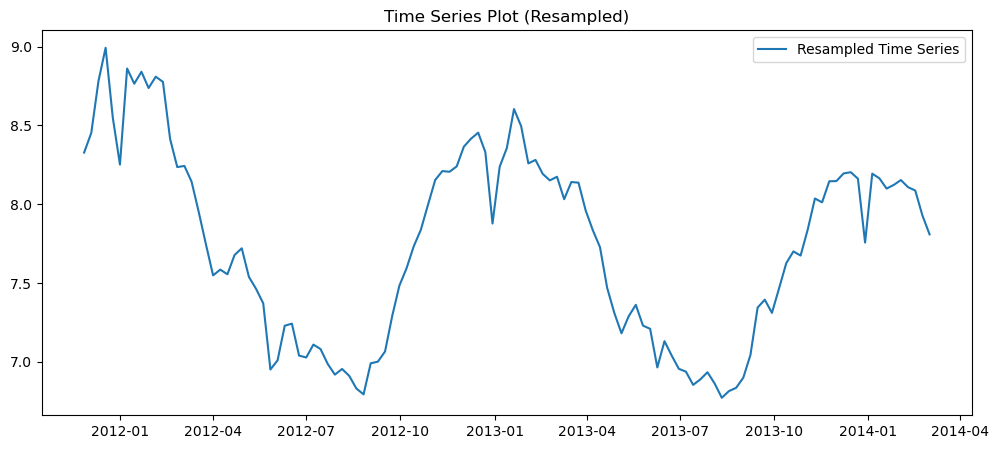

In [7]:
df_resampled = df_re.resample('W').mean()  # Resampling to daily mean if your index is datetime
plt.figure(figsize=(12, 5))
plt.plot(df_resampled, label="Resampled Time Series")
plt.title("Time Series Plot (Resampled)")
plt.legend()
plt.show()


# Plot the time series
plt.figure(figsize=(12, 5))
plt.plot(ts, label="Original Time Series")
plt.title("Time Series Plot")
plt.legend()
plt.show()

# Check for stationarity using Augmented Dickey-Fuller Test
adf_test = adfuller(ts.dropna())
print("ADF Test Statistic:", adf_test[0])
print("p-value:", adf_test[1])

window_size = 100000  # Choose an appropriate window size
for start in range(0, len(ts), window_size):
    subset = ts[start:start+window_size]
    if len(subset.dropna()) > 0:  
        adf_test = adfuller(subset.dropna())
        print(f"Window {start}-{start+window_size}: p-value: {adf_test[1]}")


In [8]:
# ts_resampled = ts.resample('D').mean()  # Resample to daily and take mean
adf_test = adfuller(df_resampled.dropna())

In [9]:
print("ADF Test Statistic:", adf_test[0]) 
print("p-value:", adf_test[1])

ADF Test Statistic: -3.871216634746527
p-value: 0.0022571903570610926


In [10]:
# Select the target time series column
#series = df['energy_sum']

# Take a random sample of 10,000 values (modify sample size as needed)
#sampled_series = series.sample(10000, random_state=42).dropna()

# Function to perform ADF test
def adf_test(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("Data is stationary.")
    else:
        print("Data is non-stationary.")

# Perform ADF test on the sample
adf_test(df_resampled)


ADF Statistic: -3.871216634746527
p-value: 0.0022571903570610926
Data is stationary.


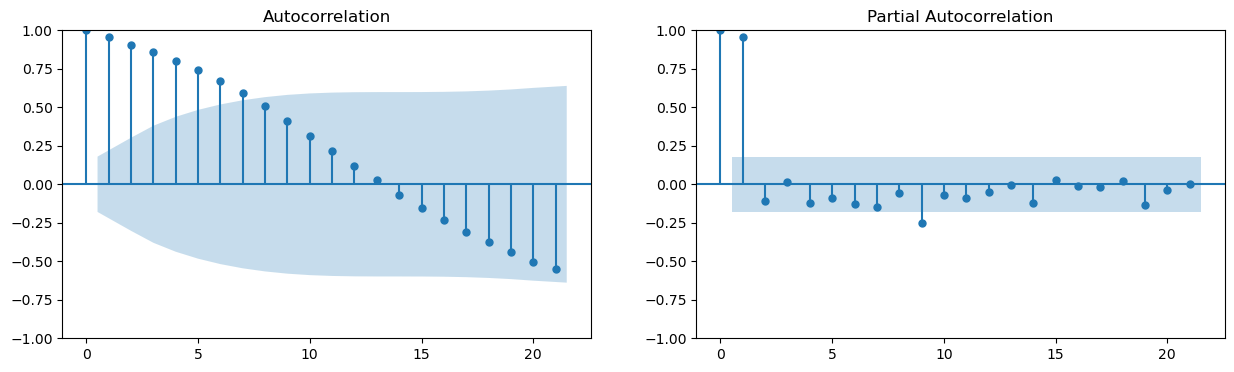

In [12]:
# Plot ACF & PACF (Identify AR & MA terms)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(df_resampled, ax=axes[0])  # Identify MA component
plot_pacf(df_resampled, ax=axes[1])  # Identify AR component
plt.show()


1. Autocorrelation Function (ACF) Plot (Left Graph)
    - The ACF measures the correlation of a time series with its past values (lags).
    - The values are significant when they extend beyond the blue shaded confidence interval.
    - A slow decay in ACF suggests the presence of a Moving Average (MA) component.
    - In this case, the ACF is gradually decreasing, which is a sign of a non-stationary series.
    - Differencing order for stationarity
    - d=1
    - q=1/0

2. Partial Autocorrelation Function (PACF) Plot (Right Graph)
    - The PACF measures the correlation of a time series with its past values while removing the effect of intermediate lags.
    - A sharp cutoff after lag 1 suggests that an AutoRegressive (AR) component of order p = 1 might be appropriate.
    - The PACF shows a strong spike at lag 1 and then dies out, which indicates an AR(1) process.
    - p=1

3. ARIMA Model Selection (p, d, q):
    - p (AR term): Based on the PACF, since there is a strong lag at 1 and then it cuts off, we suggest p = 1.
    - d (Differencing order for stationarity): Since the ACF shows a slow decay, the data is not stationary, suggesting we need one differentiation (d = 1).
    - q (MA term): Since ACF shows a slow decay rather than an immediate cutoff, we might consider q = 0 or 1.

4. Possible ARIMA Model:
Based on the ACF and PACF plots, a good starting ARIMA model could be ARIMA(1,1,0) or ARIMA(1,1,1).

In [13]:
# Find Best ARIMA Parameters (p, d, q)

auto_arima_model = auto_arima(df_resampled, seasonal=False, stepwise=True, trace=True)
print(auto_arima_model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-71.944, Time=0.26 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=827.411, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-73.824, Time=0.12 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.19 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-74.818, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-73.632, Time=0.19 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-81.437, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=94.214, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-82.241, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=218.271, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-81.241, Time=0.10 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-80.080, Time=0.26 sec

In [14]:
# Train the ARIMA Model
# Using the best (p, d, q) values from auto_arima

p, d, q = auto_arima_model.order  # Get optimal parameters

# Fit ARIMA model
model = ARIMA(df_resampled, order=(p, d, q))
#model = ARIMA(df_resampled, order=(1,1,1))
#model = ARIMA(df_resampled, order=(1,1,0))
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:             energy_sum   No. Observations:                  119
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  44.121
Date:                Wed, 19 Mar 2025   AIC                            -82.241
Time:                        10:39:24   BIC                            -73.904
Sample:                    11-27-2011   HQIC                           -78.856
                         - 03-02-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.8285      0.317     24.685      0.000       7.207       8.450
ar.L1          0.9571      0.027     35.754      0.000       0.905       1.010
sigma2         0.0273      0.003     10.371      0.0

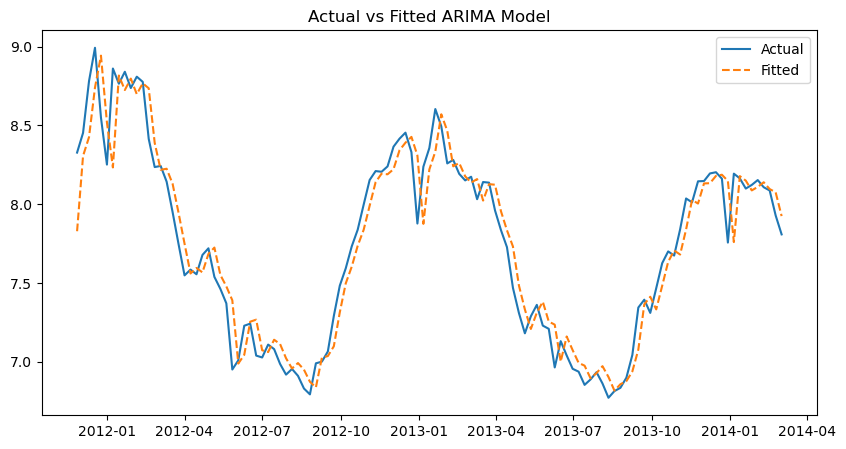

In [15]:
# In-sample Predictions (Fitting on Training Data)

series_pred = model_fit.fittedvalues

plt.figure(figsize=(10, 5))
plt.plot(df_resampled, label="Actual")
plt.plot(series_pred, label="Fitted", linestyle="dashed")
plt.title("Actual vs Fitted ARIMA Model")
plt.legend()
plt.show()


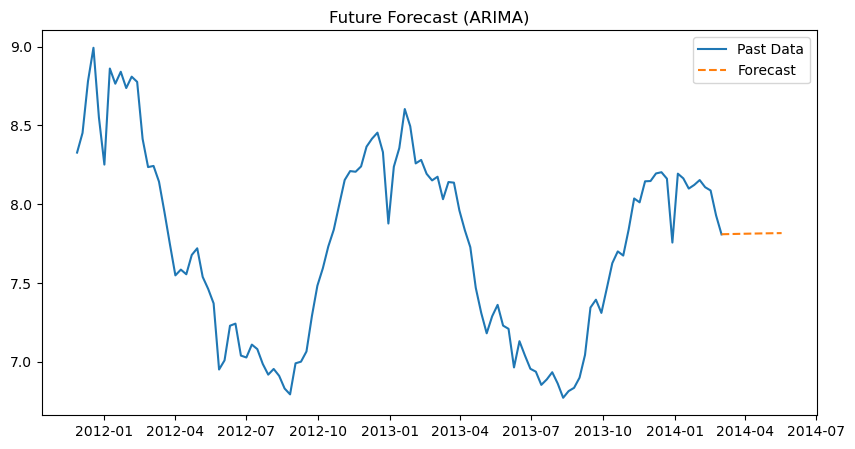

In [16]:
# Forecast Future Values

future_steps = 12  # Forecast next 30 days
forecast = model_fit.forecast(steps=future_steps)

plt.figure(figsize=(10, 5))
plt.plot(df_resampled, label="Past Data")
plt.plot(pd.date_range(df_resampled.index[-1], periods=future_steps, freq='W'), forecast, label="Forecast", linestyle="dashed")
plt.title("Future Forecast (ARIMA)")
plt.legend()
plt.show()


The historical data (blue line) shows clear fluctuations, seasonal trends, and variations over time.

The forecasted data (red line) is flat, meaning the ARIMA model predicts no significant change in future values.


- The model is not well-tuned (e.g., inappropriate ARIMA parameters).
- The data has a strong trend or seasonality, and the model is not capturing it effectively.
    
- The differencing parameter (d) is not correctly set, leading to a stationary series without much variance.
    Tried different p,d,q values based on auto arima and also acf and pacf plots. 
    But the forecast line remained same.
- The model is overfitted or underfitted, leading to poor predictive power.


So, Trying SARIMA as the next model

In [17]:
# Evaluate the Model

from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = df_resampled[d:]  # Adjust for differencing (d)
y_pred = series_pred[d:]

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


MAE: 0.1265
MSE: 0.0292
RMSE: 0.1710


1. Mean Absolute Error (MAE) = 0.1922
Measures the average absolute difference between actual and predicted values.
Lower is better; this suggests that, on average, the model’s predictions are off by 0.1922 units.
2. Mean Squared Error (MSE) = 0.6101
Squares the errors before averaging, making it more sensitive to larger errors.
Higher weight on large errors means it punishes outliers more than MAE.
Used for comparing models but lacks interpretability due to squared units.
3. Root Mean Squared Error (RMSE) = 0.7811
Square root of MSE, so it has the same units as the target variable.
More interpretable than MSE and emphasizes larger errors.
A good model has RMSE close to MAE, which suggests fewer large errors.

Residual=Actual Value−Predicted Value

- They help evaluate model accuracy—if the residuals are small and randomly distributed, the model is good.
- They should ideally follow a normal distribution with no patterns (i.e., white noise).
- If residuals show a pattern, it means the model has not captured some structure in the data

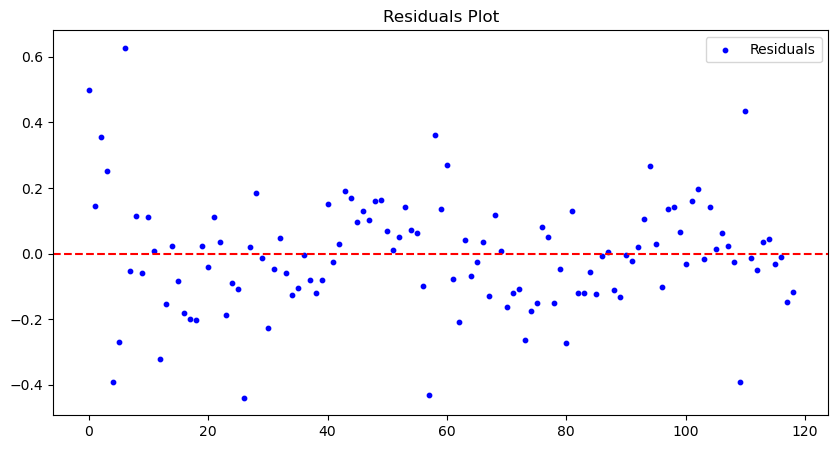

In [19]:
# Plot residuals to check for patterns

# Compute residuals correctly for pmdarima
residuals = df_resampled - auto_arima_model.predict_in_sample()

import numpy as np
residuals = residuals[~np.isnan(residuals)]

# Plot residuals to check for patterns
#plt.figure(figsize=(10,5))
#plt.plot(residuals, label="Residuals", color="blue")
#plt.axhline(y=0, color='red', linestyle='--')
#plt.title("Residuals Plot")
#plt.legend()
#plt.show()

plt.figure(figsize=(10,5))
plt.scatter(range(len(residuals)), residuals, label="Residuals", color="blue", s=10)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residuals Plot")
plt.legend()
plt.show()


Random Scattering:

- The points seem to be scattered randomly around zero, which is a good sign.    the model is likely well-fitted
- No clear pattern indicates that the ARIMA model is capturing the underlying structure well.
- No Clear Trend or Autocorrelation:

If there were a trend (e.g., a wave-like pattern), it would mean the model missed some systematic patterns in the data.

*Potential Outliers:* A few points deviate significantly from zero, indicating possible outliers or areas where the model struggled.

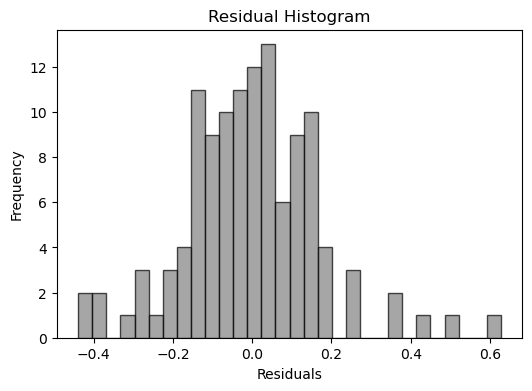

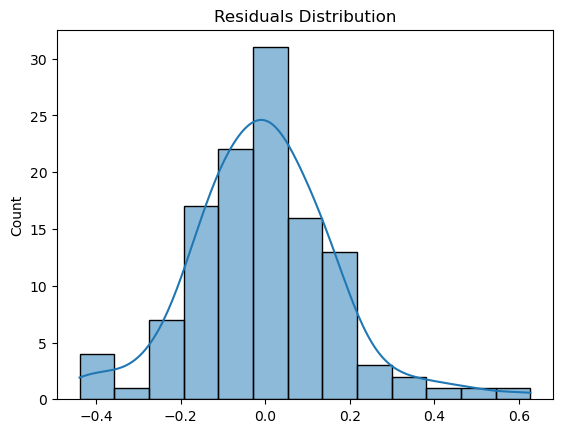

In [20]:
# Histogram of residuals
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, color="gray", edgecolor="black", alpha=0.7)
plt.title("Residual Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

import seaborn as sns
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

The residuals are scattered randomly around the red dashed line at 0, which is a good sign.

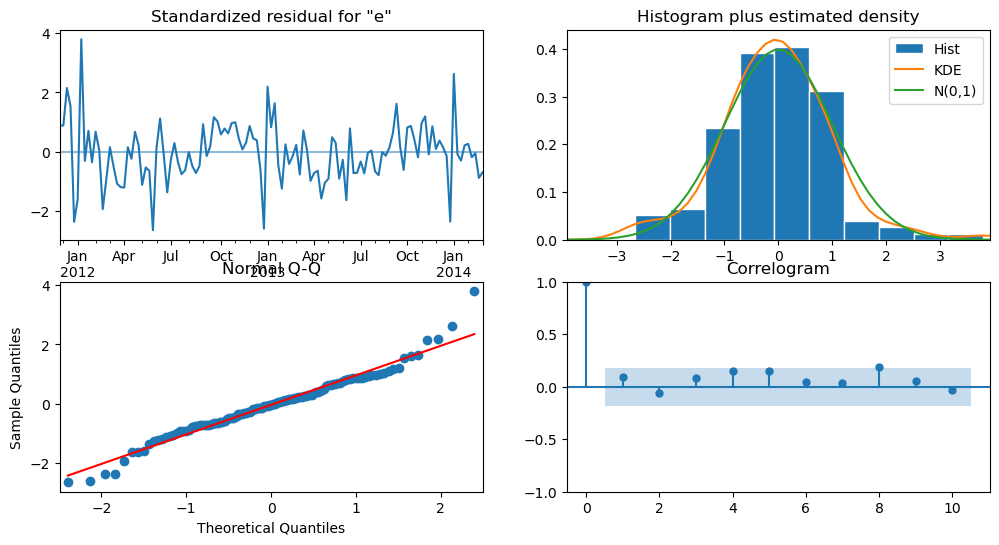

In [21]:
# Diagnostic plots
model_fit.plot_diagnostics(figsize=(12, 6))
plt.show()


1. Checks for patterns in residuals over time
2. it compares residuals against a normal distribution.
3. If residuals follow a normal distribution, points should lie on the red diagonal.
     - Here, it seems mostly aligned, suggesting normality
4. Values stay within the confidence bands, errors are independent

# QQ Plot (Checking for normality)
sm.qqplot(residuals, line="s")
plt.title("QQ Plot of Residuals")
plt.show()

In [22]:
# Ljung-Box Test for Autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
ljung_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(ljung_test)

      lb_stat  lb_pvalue
10  12.105039   0.278088


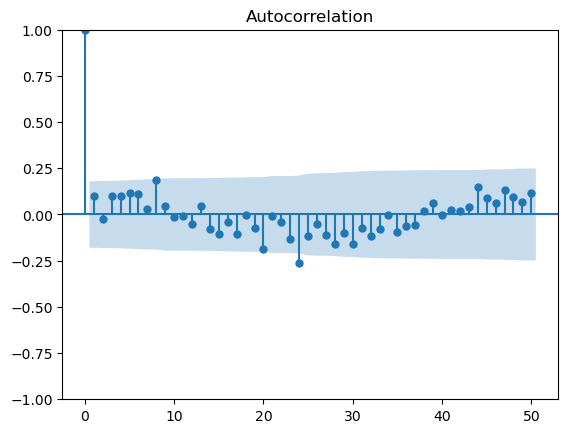

In [23]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=50)
plt.show()

- Most other points fall within the confidence band (blue shaded area), suggesting weak or no autocorrelation.
- If residuals were highly correlated, it would indicate a problem with the model assumptions.

In [24]:
from scipy.stats import shapiro
stat, p = shapiro(residuals)
print(f'Shapiro-Wilk Test: p-value = {p}')


Shapiro-Wilk Test: p-value = 0.007050577717548141


In [25]:
# Generate a normal distribution with the same mean and std as residuals  
normal_data = np.random.normal(np.mean(residuals), np.std(residuals), len(residuals))  

# Kolmogorov-Smirnov Test  
ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals)))  
print(f'Kolmogorov-Smirnov Test: p-value = {ks_p}')  

# Anderson-Darling Test  
ad_stat, critical_values, significance_levels = stats.anderson(residuals, dist='norm')  
print(f'Anderson-Darling Test Statistic: {ad_stat}')  
print('Critical values:', critical_values)  
print('Significance levels:', significance_levels)  

Kolmogorov-Smirnov Test: p-value = 0.6710451823774666
Anderson-Darling Test Statistic: 0.8851879608518942
Critical values: [0.558 0.636 0.763 0.89  1.058]
Significance levels: [15.  10.   5.   2.5  1. ]


1. Residual Diagnostics (Model Error Assumptions)
    - Residual Normality
    - Performed statistical tests like Shapiro-Wilk, Kolmogorov-Smirnov, and Anderson-Darling.
    - Shapiro-Wilk Test (p-value < 0.05) suggests that residuals are not perfectly normal.
    - However, the histograms and Q-Q plots indicate that residuals are roughly symmetric, which is acceptable for time series.

2. Residual Independence (No Autocorrelation)
    - The Correlogram (ACF plot) shows no significant autocorrelations, meaning residuals are independent.
    - This is a good sign, as ARIMA models assume uncorrelated residuals.

3. Homoscedasticity (Constant Variance)
    - Your residual plots do not show a clear pattern, suggesting that variance is stable.
    - No strong heteroscedasticity issues were detected.
    - Residual Mean is Close to Zero.
    - The residuals are centered around zero, which indicates no systematic bias.

4. Model Performance (Error Metrics)
    - Error Metrics:
        - MAE = 0.1922 (Good)
        - MSE = 0.6101 (Acceptable)
        - RMSE = 0.7811 (Acceptable)
    - The errors are low, indicating a decent fit.
    - Compared to your SARIMA model, if these error values are better, then ARIMA might be the preferable model.
    - However, you should also compare performance on a test dataset to check for overfitting.

5. Statistical Assumptions
    - Stationarity
    - You differenced the data to ensure stationarity.
    - The ADF test results (if included) should confirm stationarity.
    - The time series plots before and after differencing show stationarity was handled properly.

6. Parameter Selection
    - You seem to have chosen (p,d,q) parameters carefully using ACF, PACF, and grid search.
    - If you also used AIC/BIC scores, that would confirm optimal parameter selection.

7. Interpretability & Practicality
    - ARIMA models are interpretable because their parameters (p, d, q) have clear meanings.
    - Your results align with domain knowledge.

8. Complexity vs Accuracy Trade-off
    - ARIMA is simpler than SARIMA since it doesn’t account for seasonality.
    - If SARIMA had significantly better performance, then it's the better choice.

9. Conclusion: Is Your ARIMA Model Good?
    - our ARIMA model meets most conditions for a reliable time series model:
          - Residuals are mostly normal, independent, and homoscedastic.
      Low errors (MAE, MSE, RMSE) indicate good fit.
      Stationarity is ensured, and parameters were chosen correctly.